# 08 — Первая нейросеть на Titanic: собираем сами в PyTorch

Это рабочая тетрадь: ты сам подготовишь тензоры, опишешь сеть и напишешь цикл обучения.
На выходе — небольшая полносвязная сеть **MLP**, которая оценивает вероятность
`Survived = 1`, графики обучения и сравнение с простыми моделями.
Достаточно знать основы Python, pandas и идею train/validation split.

**Как проходить:** читай объяснение → дописывай `TODO` → запускай ячейку → проходи
проверку ниже → записывай наблюдение. В заданиях стоит `NotImplementedError`:
это намеренная остановка. Удали её, когда допишешь код. Служебные части уже готовы.
Подсказки и решения спрятаны под раскрывающимися блоками. Если просмотрщик их
не раскрывает, открой notebook в JupyterLab или VS Code.

| Занятие | Шаги | Что получится |
|---|---|---|
| 1. От таблицы к батчу | 0–5 | Данные без пропусков, тензоры и DataLoader |
| 2. Как сеть учится | 6–11 | Своя модель, градиенты и цикл обучения |
| 3. Что получилось | 12–15 | Метрики, ошибки, предсказания и сохранение |

Здесь используем простые исходные признаки Titanic и отдельное разбиение 80/20.
Validation помогает выбирать эпоху и разбирать обучение; её оценка после подбора
настроек может быть оптимистичной. Результаты из проектного 5-fold CV напрямую
с этим числом не сравниваем. Одинаковый split для локальных baseline будет ниже.

После прохождения перенесём понятные тебе части в стандартный notebook шаблона:
конфигурация, folds, обучение, артефакты и отчёт. Сейчас весь учебный код виден здесь.


## 0. Окружение и воспроизводимость

Выбери kernel **Python (titanik-ml)**. Первая ячейка показывает, какой Python
действительно выполняет код. Для этого упражнения достаточно CPU.

Если PyTorch ещё не установлен, выполни в отдельной code-ячейке:

```python
%pip install torch --index-url https://download.pytorch.org/whl/cpu
```

После установки перезапусти kernel. Остальные зависимости уже перечислены
в `requirements.txt` проекта. Команда `%pip` устанавливает пакет в окружение kernel.
Другую сборку можно выбрать в [официальном установщике PyTorch](https://pytorch.org/get-started/locally/).


In [1]:
from pathlib import Path
import sys

print("Python:", sys.executable)
current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (current_dir, *current_dir.parents)
     if (p / "src/ml_project/config.py").is_file() and (p / "data/raw").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Открой notebook из папки проекта или notebooks/.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Проект:", PROJECT_ROOT)


Python: C:\ML_Progs\Runtimes\Miniforge3\envs\titanik-ml\python.exe
Проект: D:\Projects\Titanik-ML-project


In [2]:
import copy
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, log_loss, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Установи torch командой из шага 0, затем перезапусти kernel."
    ) from exc
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from ml_project.config import DATASETS, RAW_DIR, TARGET, KEY, TRAIN_DATASET, INFERENCE_DATASET

SEED = 42
DEVICE = torch.device("cpu")
# Для маленькой таблицы ограничим число CPU-потоков.
torch.set_num_threads(1)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(SEED)
print({"torch": torch.__version__, "sklearn": sklearn.__version__, "device": str(DEVICE)})
print("Seed фиксирует старт, но не обещает побитовое совпадение между версиями и устройствами.")


{'torch': '2.14.0+cpu', 'sklearn': '1.9.0', 'device': 'cpu'}
Seed фиксирует старт, но не обещает побитовое совпадение между версиями и устройствами.


## 1. Какие данные подаём в сеть

Одна строка — пассажир. `Survived` — ответ: 0 или 1. Из `train.csv` выделим
часть для обучения и часть для проверки. Kaggle `test.csv` не содержит ответов;
он понадобится только в конце для предсказаний.

Начнём с семи признаков: возраст, стоимость билета, число родственников,
пол, порт посадки и класс. `Pclass` закодируем как категорию: номера классов
не задают равные числовые расстояния. `PassengerId` исключаем из входа модели.
Сложные признаки из EXP-модулей можно подключить после освоения обучения.


In [4]:
train_path = PROJECT_ROOT / RAW_DIR / DATASETS[TRAIN_DATASET]["filename"]
df = pd.read_csv(train_path)
NUMERIC_FEATURES = ["Age", "Fare", "SibSp", "Parch"]
CATEGORICAL_FEATURES = ["Sex", "Embarked", "Pclass"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

assert TARGET == "Survived" and KEY == "PassengerId", "Эта тетрадь написана для Titanic."
assert df[KEY].is_unique
assert df[TARGET].notna().all() and set(df[TARGET].unique()) == {0, 1}
assert TARGET not in FEATURES and KEY not in FEATURES
X = df.loc[:, FEATURES].copy()
y = df[TARGET].astype("int64")

print("Размер таблицы:", df.shape)
display(df.head(3))
display(pd.DataFrame({"dtype": X.dtypes, "missing": X.isna().sum()}))
display(y.value_counts(normalize=True).rename("доля класса"))


Размер таблицы: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


,dtype,missing
Age,float64,177
Fare,float64,0
SibSp,int64,0
Parch,int64,0
Sex,str,0
Embarked,str,2
Pclass,int64,0


Survived
0    0.616162
1    0.383838
Name: доля класса, dtype: float64

**Запиши до обучения:** что должна выдавать сеть — класс, вероятность или число,
из которого получаем вероятность? Какую accuracy даст постоянный ответ 0?

Мой ответ: …


## 2. Отделяем validation до подготовки данных

**Задание 1.** Получи `X_train`, `X_val`, `y_train`, `y_val` через
`train_test_split`. Отложи 20%, зафиксируй `random_state=SEED` и сохрани
доли классов с помощью `stratify=y`.

Сначала split, потом fit заполнения пропусков и масштабирования: иначе информация
из validation попадёт в обучение. Индексы пока сохраняй — они пригодятся для анализа ошибок.


In [5]:
# TODO: разбей X и y на обучающую и валидационную части.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y,
)

<details>
<summary>Подсказка</summary>

Порядок четырёх результатов: X для обучения, X для validation, y для обучения,
y для validation. Стратификация задаётся исходным вектором y.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y,
)
```

</details>


In [6]:
assert set(X_train.index).isdisjoint(X_val.index), "Части пересекаются."
assert len(X_train) + len(X_val) == len(df)
assert X_train.index.equals(y_train.index) and X_val.index.equals(y_val.index)
assert set(y_train.unique()) == set(y_val.unique()) == {0, 1}
display(pd.DataFrame({
    "rows": [len(X_train), len(X_val)],
    "survived_share": [y_train.mean(), y_val.mean()],
}, index=["train", "validation"]))


,rows,survived_share
train,712,0.383427
validation,179,0.385475


## 3. Готовый мост: pandas → числовая матрица

Эту часть можно выполнить как есть, чтобы сосредоточиться на PyTorch.
Числа заполняем медианой и стандартизуем: `(x − среднее) / std`.
Это приводит возраст и цену билета к сопоставимому масштабу.
Категории заполняем самым частым значением и кодируем отдельными 0/1 столбцами.

Все статистики учим **только на X_train**. Для validation используем
`transform`. Плотная матрица удобна для небольшой сети, поэтому задано
`sparse_output=False`. `handle_unknown="ignore"` позволяет обработать новую
категорию: её one-hot блок будет нулевым. См. [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

Число входов сети определим **после** кодирования: оно уже не обязано равняться семи.


In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
])

X_train_np = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_np = preprocessor.transform(X_val).astype(np.float32)
feature_names = preprocessor.get_feature_names_out()
INPUT_DIM = X_train_np.shape[1]

assert X_train_np.shape == (len(y_train), INPUT_DIM)
assert X_val_np.shape == (len(y_val), INPUT_DIM)
assert np.isfinite(X_train_np).all() and np.isfinite(X_val_np).all()
print("Число входов:", INPUT_DIM)
display(pd.DataFrame(X_train_np[:5], columns=feature_names))


Число входов: 12


,numeric__Age,numeric__Fare,numeric__SibSp,numeric__Parch,categorical__Sex_female,categorical__Sex_male,categorical__Embarked_C,categorical__Embarked_Q,categorical__Embarked_S,categorical__Pclass_1,categorical__Pclass_2,categorical__Pclass_3
0,-0.081135,0.513812,-0.465084,-0.466183,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-0.081135,-0.662563,-0.465084,-0.466183,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.081135,3.955399,-0.465084,-0.466183,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.887827,-0.467874,-0.465084,0.727782,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.110934,-0.115977,0.478335,0.727782,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 4. Превращаем массивы в тензоры

Тензор здесь — массив чисел с формой (`shape`), типом (`dtype`) и устройством
(`device`). PyTorch умеет считать производные операций над такими массивами.

**Задание 2.** Создай `X_train_t`, `X_val_t`, `y_train_t`, `y_val_t`.
У всех тип `torch.float32`. X имеет форму `[число строк, INPUT_DIM]`,
а y — `[число строк]`. Для выбранного binary loss метки тоже вещественные: 0.0/1.0.
Входным данным `requires_grad=True` не нужен: обучаться будут веса сети.


In [8]:
# TODO: torch.tensor(..., dtype=torch.float32); у Series сначала возьми to_numpy().
X_train_t= torch.tensor(X_train_np, dtype=torch.float32)
X_val_t = torch.tensor(X_val_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(), dtype=torch.float32)

<details>
<summary>Подсказка</summary>

NumPy и PyTorch — разные библиотеки. Здесь явно копируем небольшие массивы
через torch.tensor. Индексы pandas в тензор не переносятся; порядок строк сохраняется.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
X_val_t = torch.tensor(X_val_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
```

</details>


In [9]:
for name, tensor, shape in [
    ("X_train", X_train_t, (len(X_train), INPUT_DIM)),
    ("X_val", X_val_t, (len(X_val), INPUT_DIM)),
    ("y_train", y_train_t, (len(y_train),)),
    ("y_val", y_val_t, (len(y_val),)),
]:
    assert tensor.shape == shape, f"{name}: ожидается {shape}, получено {tensor.shape}"
    assert tensor.dtype == torch.float32 and torch.isfinite(tensor).all()
    print(name, tuple(tensor.shape), tensor.dtype, tensor.device)
assert torch.equal(y_train_t, torch.tensor(y_train.to_numpy(), dtype=torch.float32))
assert torch.equal(y_val_t, torch.tensor(y_val.to_numpy(), dtype=torch.float32))


X_train (712, 12) torch.float32 cpu
X_val (179, 12) torch.float32 cpu
y_train (712,) torch.float32 cpu
y_val (179,) torch.float32 cpu


## 5. Dataset и DataLoader: выдаём данные порциями

`TensorDataset` связывает признаки пассажира с его ответом. `DataLoader`
выдаёт **батчи** — небольшие порции данных. Один проход по всем обучающим
батчам называется **эпохой**. Внутри эпохи веса обновляются много раз.

**Задание 3.** Создай два `TensorDataset` и три `DataLoader`:
`train_loader` с перемешиванием, `train_eval_loader` и `val_loader` без него.
Размер батча 32, `num_workers=0` (простой запуск внутри Windows notebook),
последний неполный батч сохраняем. Для train используй генератор с seed.
`train_eval_loader` нужен для измерения качества на train при фиксированных весах.


In [10]:
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)
train_eval_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

<details>
<summary>Подсказка</summary>

TensorDataset принимает пару тензоров X и y; DataLoader принимает получившийся dataset.
shuffle=True перемешивает пары целиком: признаки и ответы не расходятся.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)
train_eval_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)
```

</details>


In [11]:
xb, yb = next(iter(train_loader))
assert xb.shape == (BATCH_SIZE, INPUT_DIM) and yb.shape == (BATCH_SIZE,)
assert sum(len(batch_y) for _, batch_y in train_loader) == len(y_train)
assert torch.equal(torch.cat([batch_y for _, batch_y in val_loader]), y_val_t)
print("Батч:", xb.shape, yb.shape)
print("Обновлений весов за эпоху:", len(train_loader))
print("Строк в последнем train-батче:", len(list(train_eval_loader)[-1][1]))


Батч: torch.Size([32, 12]) torch.Size([32])
Обновлений весов за эпоху: 23
Строк в последнем train-батче: 8


**Пауза после первого занятия.** Объясни своими словами: почему fit выполняется
только на train; почему входов стало больше семи; чем батч отличается от эпохи.

Мои заметки: …


## 6. Описываем нейросеть

Соберём сеть с одним скрытым слоем. `nn.Linear(a, b)` считает взвешенные суммы
и смещения: из `a` чисел делает `b`. `ReLU` заменяет отрицательные значения нулями,
добавляя нелинейность. Без нелинейности несколько Linear подряд эквивалентны одному.

```text
Пассажиры в батче   Linear         ReLU         Linear       squeeze(-1)
[B, INPUT_DIM]  →  [B, 32]   →    [B, 32]   →   [B, 1]   →    [B]
                                                               logits
```

**Задание 4.** В `__init__` запиши слои в `self.net = nn.Sequential(...)`.
В `forward` пропусти x через self.net и убери только последнюю размерность.
Последний Linear возвращает один **логит** — произвольное вещественное число.
Вероятность получим отдельно. Используй `squeeze(-1)`, чтобы батч из одной строки
не превратился в скаляр.


In [12]:
class TitanicMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        # TODO: верни логиты формы [batch_size].
        return self.net(x).squeeze(-1)


<details>
<summary>Подсказка</summary>

nn.Module регистрирует слои и их параметры, когда ты присваиваешь их self.net.
forward описывает вычисление; вызывай модель как model(x), а не model.forward(x).

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
class TitanicMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
```

</details>


In [13]:
HIDDEN_DIM = 32
seed_everything(SEED)
model = TitanicMLP(INPUT_DIM, HIDDEN_DIM).to(DEVICE)
with torch.no_grad():
    assert model(xb.to(DEVICE)).shape == (len(xb),)
    assert model(X_train_t[:1].to(DEVICE)).shape == (1,)
print(model)
display(pd.DataFrame([
    {"parameter": name, "shape": tuple(p.shape), "count": p.numel()}
    for name, p in model.named_parameters()
]))
print("Обучаемых параметров:", sum(p.numel() for p in model.parameters() if p.requires_grad))


TitanicMLP(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


,parameter,shape,count
0,net.0.weight,"(32, 12)",384
1,net.0.bias,"(32,)",32
2,net.2.weight,"(1, 32)",32
3,net.2.bias,"(1,)",1


Обучаемых параметров: 449


**Посчитай вручную:** у слоя Linear(a, b) есть `a × b` весов и `b` смещений.
Сколько параметров у твоей сети? Что меняется при hidden_dim=64?

Мой расчёт: …


## 7. Логит → вероятность → класс

Sigmoid переводит логит z в число `p = 1 / (1 + exp(-z))` от 0 до 1.
Логит 0 означает вероятность 0.5; положительный логит — вероятность выше 0.5.

**Задание 5.** Для примера ниже посчитай `demo_probabilities` через `torch.sigmoid`,
затем `demo_predictions` с порогом 0.5. Это отдельное преобразование на этапе
интерпретации предсказаний; в саму сеть Sigmoid сейчас не добавляй.


In [14]:
demo_logits = torch.tensor([-2.0, 0.0, 2.0])
THRESHOLD = 0.5
demo_probabilities = torch.sigmoid(demo_logits)
demo_predictions = (demo_probabilities >= THRESHOLD).to(torch.int64)

<details>
<summary>Подсказка</summary>

Сравнение >= возвращает булев тензор. Метод .to(torch.int64) превращает False/True в 0/1.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
demo_logits = torch.tensor([-2.0, 0.0, 2.0])
THRESHOLD = 0.5
demo_probabilities = torch.sigmoid(demo_logits)
demo_predictions = (demo_probabilities >= THRESHOLD).to(torch.int64)
```

</details>


In [15]:
assert torch.allclose(demo_probabilities, torch.tensor([0.1192029, 0.5, 0.8807971]))
assert demo_predictions.tolist() == [0, 1, 1]
display(pd.DataFrame({
    "logit": demo_logits.numpy(), "probability": demo_probabilities.numpy(),
    "prediction": demo_predictions.numpy(),
}))


,logit,probability,prediction
0,-2.0,0.119203,0
1,0.0,0.500000,1
2,2.0,0.880797,1


## 8. Откуда берётся обучение: autograd

Упрощённый пример с одним весом: `prediction = w × x`,
`loss = (prediction − target)²`. Здесь квадрат ошибки выбран для наглядной
производной; для Titanic ниже используем другой loss.

`backward()` вычисляет градиент — производную loss по весу — и кладёт его в `.grad`.
Сам вес от этого ещё не меняется. Его обновит optimizer на следующем шаге.


In [16]:
w = torch.tensor(2.0, requires_grad=True)
toy_x = torch.tensor(3.0)
toy_target = torch.tensor(1.0)
toy_prediction = w * toy_x
toy_loss = (toy_prediction - toy_target) ** 2
toy_loss.backward()
print("prediction:", toy_prediction.item(), "loss:", toy_loss.item())
print("w.grad:", w.grad.item(), "w после backward:", w.item())
assert w.grad.item() == 30.0  # 2 * (2*3 - 1) * 3
assert w.item() == 2.0       # backward не обновляет вес


prediction: 6.0 loss: 25.0
w.grad: 30.0 w после backward: 2.0


**Предскажи:** если уменьшить w на `0.01 × w.grad`, новый loss станет меньше или больше?
Почему нельзя просто присвоить loss ноль и считать сеть обученной?

Мой ответ: …


## 9. Loss и optimizer

**Loss** — гладкая мера ошибки, по которой учим веса. **Accuracy** — доля верных
классов, которой оцениваем результат. Пороговое решение не даёт полезного
градиента для обучения, поэтому оптимизируем другой критерий.

`BCEWithLogitsLoss` принимает сырые логиты и float-метки той же формы.
Внутри уже объединены Sigmoid и binary cross-entropy для устойчивого вычисления:
передавать туда вероятность после Sigmoid не нужно.
См. [документацию BCEWithLogitsLoss](https://docs.pytorch.org/docs/2.9/generated/torch.nn.BCEWithLogitsLoss.html).

**Задание 6.** Создай `loss_fn = nn.BCEWithLogitsLoss()` и Adam для
`model.parameters()` с `lr=1e-3`. Learning rate задаёт масштаб обновления весов.


In [17]:
LEARNING_RATE = 1e-3
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

<details>
<summary>Подсказка</summary>

Optimizer должен получить параметры конкретного экземпляра сети.
Если пересоздал model, пересоздай и optimizer: старый останется связан со старыми весами.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
LEARNING_RATE = 1e-3
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
```

</details>


In [18]:
with torch.no_grad():
    batch_logits = model(xb.to(DEVICE))
    batch_loss = loss_fn(batch_logits, yb.to(DEVICE))
assert batch_logits.shape == yb.shape
assert batch_loss.ndim == 0 and torch.isfinite(batch_loss)
assert {id(p) for group in optimizer.param_groups for p in group["params"]} == {
    id(p) for p in model.parameters()
}
print("Loss до обучения:", batch_loss.item())
print("Для нулевых логитов loss:", loss_fn(torch.zeros_like(yb), yb).item())


Loss до обучения: 0.726277232170105
Для нулевых логитов loss: 0.6931471824645996


## 10. Одно обновление весов — главные пять строк

**Задание 7.** На копии сети выполни один шаг:
обнули градиенты → получи логиты → посчитай loss → вызови backward → обнови веса.
Копия позволяет изучить шаг, не меняя старт основной сети.

`model.train()` включает режим обучения слоёв; сам по себе он ничего не обучает.
`zero_grad()` нужен потому, что градиенты в PyTorch по умолчанию накапливаются.
Порядок операций разобран в [официальном уроке про оптимизацию](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).


In [19]:
demo_model = copy.deepcopy(model)
demo_optimizer = torch.optim.Adam(demo_model.parameters(), lr=LEARNING_RATE)
demo_model.train()
before = {name: p.detach().clone() for name, p in demo_model.named_parameters()}
xb_demo, yb_demo = xb.to(DEVICE), yb.to(DEVICE)

# TODO: zero_grad -> forward -> loss -> backward -> step; назови loss step_loss.
demo_optimizer.zero_grad()
step_logits = demo_model(xb_demo)
step_loss = loss_fn(step_logits, yb_demo)
step_loss.backward()
demo_optimizer.step()

<details>
<summary>Подсказка</summary>

backward вызывается у тензора loss, а zero_grad и step — у optimizer.
Используй step_loss.backward(), а не step_loss.item().backward(): .item() возвращает Python-число.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
demo_model = copy.deepcopy(model)
demo_optimizer = torch.optim.Adam(demo_model.parameters(), lr=LEARNING_RATE)
demo_model.train()
before = {name: p.detach().clone() for name, p in demo_model.named_parameters()}
xb_demo, yb_demo = xb.to(DEVICE), yb.to(DEVICE)

demo_optimizer.zero_grad()
step_logits = demo_model(xb_demo)
step_loss = loss_fn(step_logits, yb_demo)
step_loss.backward()
demo_optimizer.step()
```

</details>


In [20]:
assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in demo_model.parameters())
max_change = max(
    (p.detach() - before[name]).abs().max().item()
    for name, p in demo_model.named_parameters()
)
assert max_change > 0, "Вес не изменился: проверь backward, step и связь optimizer с сетью."
print("Loss на батче до обновления:", step_loss.item())
print("Максимальное изменение параметра:", max_change)
print("Один шаг не гарантирует уменьшение loss на каждом следующем батче.")


Loss на батче до обновления: 0.726277232170105
Максимальное изменение параметра: 0.0010000020265579224
Один шаг не гарантирует уменьшение loss на каждом следующем батче.


## 11. От одного шага к полному обучению

### 11.1. Обучаем одну эпоху

**Задание 8.** Перенеси пять операций в цикл по loader. Возвращай средний loss
по **пассажирам**, а не среднее средних батчей: последний батч может быть короче.
Для этого умножай `loss.item()` на размер батча и в конце дели сумму на число строк.

`.to(device)` переносит батч туда же, где лежат веса. Пока всё находится на CPU.


In [22]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    total_rows = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        total_rows += len(yb)
    return total_loss / total_rows

<details>
<summary>Подсказка</summary>

В статистику записывай .item(), чтобы не хранить вычислительные графы всех батчей.
Веса меняются в течение эпохи: этот loss усредняет предсказания разных состояний сети.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    total_rows = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        total_rows += len(yb)
    return total_loss / total_rows
```

</details>


### 11.2. Оцениваем модель без обновления весов

**Задание 9.** Напиши `evaluate`: включи `model.eval()`, пройди по loader внутри
`torch.no_grad()`, посчитай средний loss и accuracy. Верни словарь с ключами
`loss` и `accuracy`. Класс получай по `torch.sigmoid(logits) >= threshold`.

Здесь нет backward и optimizer.step. `eval()` переключает поведение, например,
Dropout, а `no_grad()` отключает построение графа производных — это разные задачи.
Наша первая сеть содержит только Linear/ReLU, но эта привычка пригодится при расширении.


In [23]:
def evaluate(model, loader, loss_fn, device, threshold=0.5):
    model.eval()
    total_loss, total_correct, total_rows = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            predictions = (torch.sigmoid(logits) >= threshold)
            total_loss += loss.item() * len(yb)
            total_correct += (predictions == yb).sum().item()
            total_rows += len(yb)
    return {"loss": total_loss / total_rows, "accuracy": total_correct / total_rows}

<details>
<summary>Подсказка</summary>

Весь цикл оценки помести под with torch.no_grad():.
Для accuracy сложи число верных ответов во всех батчах и раздели на число пассажиров.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
def evaluate(model, loader, loss_fn, device, threshold=0.5):
    model.eval()
    total_loss, total_correct, total_rows = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            predictions = (torch.sigmoid(logits) >= threshold)
            total_loss += loss.item() * len(yb)
            total_correct += (predictions == yb).sum().item()
            total_rows += len(yb)
    return {"loss": total_loss / total_rows, "accuracy": total_correct / total_rows}
```

</details>


In [24]:
# Проверяем функции на копии: старт основной сети остаётся прежним.
probe_model = copy.deepcopy(model)
probe_optimizer = torch.optim.Adam(probe_model.parameters(), lr=LEARNING_RATE)
probe_before = copy.deepcopy(probe_model.state_dict())
probe_train_loss = train_one_epoch(probe_model, train_loader, loss_fn, probe_optimizer, DEVICE)
assert np.isfinite(probe_train_loss)
assert any(not torch.equal(probe_before[k], v) for k, v in probe_model.state_dict().items())

probe_before_eval = copy.deepcopy(probe_model.state_dict())
probe_metrics = evaluate(probe_model, val_loader, loss_fn, DEVICE, THRESHOLD)
assert all(torch.equal(probe_before_eval[k], v) for k, v in probe_model.state_dict().items()), "Оценка меняет веса."
assert np.isfinite(probe_metrics["loss"]) and 0 <= probe_metrics["accuracy"] <= 1
# Прямая проверка на всей validation ловит неверное усреднение последнего батча.
with torch.no_grad():
    direct_logits = probe_model(X_val_t.to(DEVICE))
    direct_loss = loss_fn(direct_logits, y_val_t.to(DEVICE)).item()
    direct_pred = (torch.sigmoid(direct_logits) >= THRESHOLD).cpu().numpy()
assert np.isclose(probe_metrics["loss"], direct_loss, atol=1e-6)
assert np.isclose(probe_metrics["accuracy"], accuracy_score(y_val, direct_pred))
print("Проверка функций пройдена:", probe_metrics)


Проверка функций пройдена: {'loss': 0.6882281509857604, 'accuracy': 0.4860335195530726}


### 11.3. Учим несколько эпох и возвращаем лучшие веса

**Задание 10.** В готовом каркасе вызови `train_one_epoch`, затем два раза
`evaluate` — на train и validation. Мы заранее выбираем правило: лучшая эпоха
имеет минимальный validation loss. Сохраняй её через `copy.deepcopy(model.state_dict())`;
простая ссылка на state_dict будет меняться вместе с весами. В конце восстанови лучшие веса.

**Early stopping:** остановимся после 12 эпох без улучшения validation loss хотя бы
на 0.0001. Accuracy тоже запишем, но выбор эпохи ведём по одному заранее заданному
критерию. Это учебный подбор на validation, а не независимая финальная оценка.

Ячейка при каждом запуске заново создаёт сеть, optimizer и train_loader с тем же seed.
Чтобы начать новый опыт, меняй настройки именно здесь. После изменений в предыдущих
шагах надёжнее перезапустить kernel и пройти notebook сверху вниз.


In [26]:
MAX_EPOCHS = 100
PATIENCE = 12
MIN_DELTA = 1e-5
HIDDEN_DIM = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
BATCH_SIZE = 32

seed_everything(SEED)
model = TitanicMLP(INPUT_DIM, HIDDEN_DIM).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)
history = []
best_val_loss, best_epoch, best_state = float("inf"), 0, None
patience_reference, stale_epochs = float("inf"), 0

for epoch in range(1, MAX_EPOCHS + 1):
    optimization_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE)
    train_metrics = evaluate(model, train_eval_loader, loss_fn, DEVICE, THRESHOLD)
    val_metrics = evaluate(model, val_loader, loss_fn, DEVICE, THRESHOLD)
    assert np.isfinite([optimization_loss, train_metrics["loss"], val_metrics["loss"]]).all()
    history.append({
        "epoch": epoch, "optimization_loss": optimization_loss,
        "train_loss": train_metrics["loss"], "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"], "val_accuracy": val_metrics["accuracy"],
    })
    if val_metrics["loss"] < best_val_loss:
        best_val_loss, best_epoch = val_metrics["loss"], epoch
        best_state = copy.deepcopy(model.state_dict())
    if val_metrics["loss"] < patience_reference - MIN_DELTA:
        patience_reference, stale_epochs = val_metrics["loss"], 0
    else:
        stale_epochs += 1
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch={epoch:3d} | train loss={train_metrics['loss']:.4f} | "
              f"val loss={val_metrics['loss']:.4f} | val acc={val_metrics['accuracy']:.3f}")
    if stale_epochs >= PATIENCE:
        print("Early stopping на эпохе", epoch)
        break

model.load_state_dict(best_state)
model.eval()
history_df = pd.DataFrame(history)
print("Лучшая эпоха:", best_epoch, "| validation loss:", round(best_val_loss, 4))

epoch=  1 | train loss=0.6828 | val loss=0.6873 | val acc=0.480
epoch= 10 | train loss=0.4527 | val loss=0.4765 | val acc=0.793
epoch= 20 | train loss=0.4130 | val loss=0.4425 | val acc=0.816
epoch= 30 | train loss=0.3964 | val loss=0.4373 | val acc=0.821
epoch= 40 | train loss=0.3858 | val loss=0.4371 | val acc=0.816
Early stopping на эпохе 49
Лучшая эпоха: 37 | validation loss: 0.4365


<details>
<summary>Подсказка</summary>

В evaluate передавай train_eval_loader и val_loader. Для обучения используй train_loader.
Чтобы проверить восстановление, повторная evaluate должна вернуть best_val_loss.
state_dict хранит веса, но не код класса модели и не sklearn-preprocessor.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
MAX_EPOCHS = 100
PATIENCE = 12
MIN_DELTA = 1e-4
HIDDEN_DIM = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
BATCH_SIZE = 32

seed_everything(SEED)
model = TitanicMLP(INPUT_DIM, HIDDEN_DIM).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)
history = []
best_val_loss, best_epoch, best_state = float("inf"), 0, None
patience_reference, stale_epochs = float("inf"), 0

for epoch in range(1, MAX_EPOCHS + 1):
    optimization_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE)
    train_metrics = evaluate(model, train_eval_loader, loss_fn, DEVICE, THRESHOLD)
    val_metrics = evaluate(model, val_loader, loss_fn, DEVICE, THRESHOLD)
    assert np.isfinite([optimization_loss, train_metrics["loss"], val_metrics["loss"]]).all()
    history.append({
        "epoch": epoch, "optimization_loss": optimization_loss,
        "train_loss": train_metrics["loss"], "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"], "val_accuracy": val_metrics["accuracy"],
    })
    if val_metrics["loss"] < best_val_loss:
        best_val_loss, best_epoch = val_metrics["loss"], epoch
        best_state = copy.deepcopy(model.state_dict())
    if val_metrics["loss"] < patience_reference - MIN_DELTA:
        patience_reference, stale_epochs = val_metrics["loss"], 0
    else:
        stale_epochs += 1
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch={epoch:3d} | train loss={train_metrics['loss']:.4f} | "
              f"val loss={val_metrics['loss']:.4f} | val acc={val_metrics['accuracy']:.3f}")
    if stale_epochs >= PATIENCE:
        print("Early stopping на эпохе", epoch)
        break

model.load_state_dict(best_state)
model.eval()
history_df = pd.DataFrame(history)
print("Лучшая эпоха:", best_epoch, "| validation loss:", round(best_val_loss, 4))
```

</details>


In [27]:
restored_metrics = evaluate(model, val_loader, loss_fn, DEVICE, THRESHOLD)
assert best_state is not None and 1 <= best_epoch <= len(history_df)
assert np.isclose(restored_metrics["loss"], best_val_loss, atol=1e-6)
assert np.isclose(best_val_loss, history_df["val_loss"].min(), atol=1e-6)
assert np.isfinite(history_df.select_dtypes(include="number").to_numpy()).all()
display(history_df.tail())
print("Лучшие веса восстановлены:", restored_metrics)


,epoch,optimization_loss,train_loss,val_loss,train_accuracy,val_accuracy
44,45,0.383565,0.382117,0.437740,0.846910,0.798883
45,46,0.383060,0.381587,0.437299,0.842697,0.815642
46,47,0.382779,0.380822,0.437071,0.848315,0.810056
47,48,0.381685,0.380212,0.437454,0.844101,0.804469
48,49,0.381583,0.379557,0.437340,0.849719,0.804469


Лучшие веса восстановлены: {'loss': 0.43648183562236126, 'accuracy': 0.8212290502793296}


## 12. Читаем графики обучения

На графике train loss измерен **после эпохи**, при фиксированных весах в eval-режиме,
так же как validation loss. `optimization_loss` в таблице — средняя ошибка во время
обновлений; это другая величина.

Если train loss падает, а validation loss устойчиво растёт, сеть может переобучаться.
Если оба почти не меняются, проверь градиенты, масштаб признаков и learning rate.
Небольшие колебания validation на такой таблице ожидаемы: один пассажир меняет accuracy
примерно на `1 / len(y_val)`.


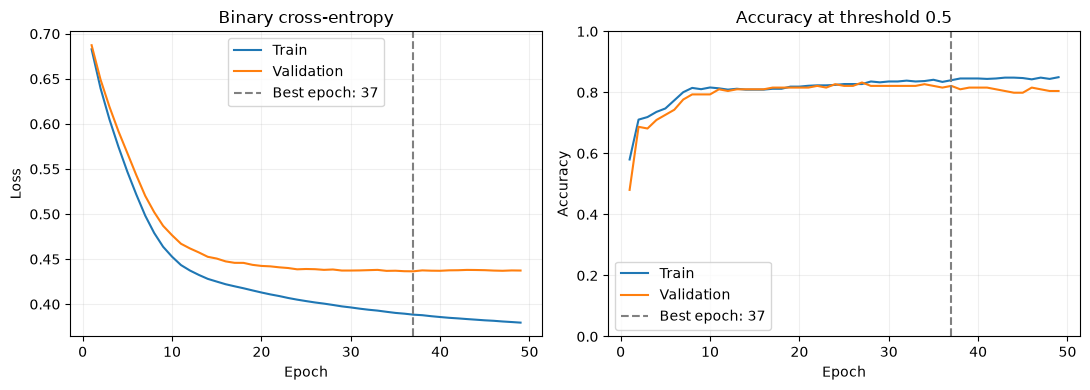

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for split, label in [("train", "Train"), ("val", "Validation")]:
    axes[0].plot(history_df["epoch"], history_df[f"{split}_loss"], label=label)
    axes[1].plot(history_df["epoch"], history_df[f"{split}_accuracy"], label=label)
for ax in axes:
    ax.axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch: {best_epoch}")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set(title="Binary cross-entropy", ylabel="Loss")
axes[1].set(title="Accuracy at threshold 0.5", ylabel="Accuracy", ylim=(0, 1))
plt.tight_layout()
plt.show()


**Мой разбор:**

- Лучшая эпоха: …
- Есть ли признаки переобучения и с какого момента: …
- Почему лучшая эпоха по loss может отличаться от лучшей по accuracy: …
- Что проверю следующим опытом: …


## 13. Сравниваем с baseline и смотрим ошибки

**Задание 11.** Напиши `predict_proba(model, X_tensor, device)`: включи eval,
отключи градиенты, получи логиты, примени Sigmoid и верни одномерный NumPy-массив
вероятностей на CPU. Для этого маленького датасета можно подать все строки сразу.

Ниже готовое сравнение с DummyClassifier и LogisticRegression: те же train/validation
строки и та же подготовка признаков. Большая нейросеть не получает преимущество
автоматически — проверяем это на данных. Здесь оцениваем выбранные на validation веса.


In [29]:
def predict_proba(model, X_tensor, device):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor.to(device))
        probabilities = torch.sigmoid(logits)
    return probabilities.cpu().numpy()

<details>
<summary>Подсказка</summary>

NumPy работает на CPU: сначала .cpu(), потом .numpy().
Внутри no_grad результат уже не требует градиентов; отдельный detach здесь не нужен.

</details>

<details>
<summary>Решение для самопроверки — открой после своей попытки</summary>

Замени им целиком ячейку задания выше, затем выполни её и проверку ниже.

```python
def predict_proba(model, X_tensor, device):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor.to(device))
        probabilities = torch.sigmoid(logits)
    return probabilities.cpu().numpy()
```

</details>


,accuracy,roc_auc,log_loss
model,,,
Dummy: most frequent,0.6145,0.5000,13.8939
Logistic regression,0.8045,0.8427,0.4622
PyTorch MLP,0.8212,0.8589,0.4365


Accuracy и ROC-AUC: выше лучше. Log loss: ниже лучше.
Один пассажир здесь меняет accuracy на 0.0056.


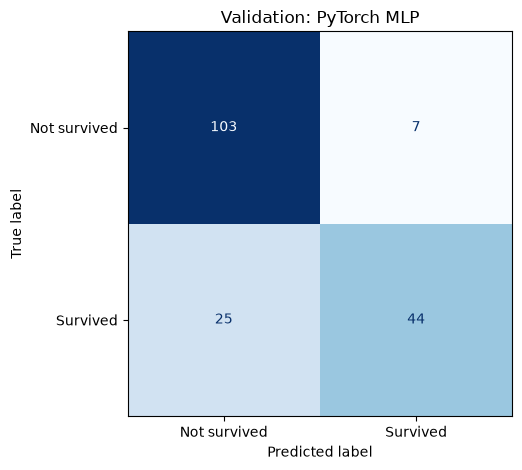

In [30]:
val_prob = predict_proba(model, X_val_t, DEVICE)
assert val_prob.shape == (len(y_val),) and np.isfinite(val_prob).all()
assert ((val_prob >= 0) & (val_prob <= 1)).all()
val_pred = (val_prob >= THRESHOLD).astype("int64")

def metric_row(name, y_true, probability, prediction):
    return {
        "model": name, "accuracy": accuracy_score(y_true, prediction),
        "roc_auc": roc_auc_score(y_true, probability),
        "log_loss": log_loss(y_true, probability, labels=[0, 1]),
    }

comparison_rows = []
for name, estimator in [
    ("Dummy: most frequent", DummyClassifier(strategy="most_frequent")),
    ("Logistic regression", LogisticRegression(max_iter=1000, random_state=SEED)),
]:
    estimator.fit(X_train_np, y_train)
    positive_index = list(estimator.classes_).index(1)
    probability = estimator.predict_proba(X_val_np)[:, positive_index]
    comparison_rows.append(metric_row(name, y_val, probability, estimator.predict(X_val_np)))
comparison_rows.append(metric_row("PyTorch MLP", y_val, val_prob, val_pred))
comparison = pd.DataFrame(comparison_rows).set_index("model")
display(comparison.round(4))
print("Accuracy и ROC-AUC: выше лучше. Log loss: ниже лучше.")
print(f"Один пассажир здесь меняет accuracy на {1 / len(y_val):.4f}.")

ConfusionMatrixDisplay.from_predictions(
    y_val, val_pred, labels=[0, 1], display_labels=["Not survived", "Survived"],
    cmap="Blues", colorbar=False,
)
plt.title("Validation: PyTorch MLP")
plt.tight_layout()
plt.show()


In [31]:
# Сохранили индексы split — можем вернуть исходные строки в правильном порядке.
error_table = df.loc[X_val.index, [KEY, "Name", *FEATURES]].copy()
error_table["actual"] = y_val.to_numpy()
error_table["probability"] = val_prob
error_table["prediction"] = val_pred
error_table["wrong"] = error_table["actual"] != error_table["prediction"]
error_table["confidence"] = np.maximum(val_prob, 1 - val_prob)
display(error_table.loc[error_table["wrong"]].sort_values("confidence", ascending=False).head(10))


,PassengerId,Name,Age,Fare,SibSp,Parch,Sex,Embarked,Pclass,actual,probability,prediction,wrong,confidence
297,298,"Allison, Miss. Helen Loraine",2.0,151.5500,1,2,female,S,1,0,0.950026,1,True,0.950026
570,571,"Harris, Mr. George",62.0,10.5000,0,0,male,S,2,1,0.050315,0,True,0.949685
199,200,"Yrois, Miss. Henriette (""Mrs Harbeck"")",24.0,13.0000,0,0,female,S,2,0,0.905190,1,True,0.905190
271,272,"Tornquist, Mr. William Henry",25.0,0.0000,0,0,male,S,3,1,0.096570,0,True,0.903430
444,445,"Johannesen-Bratthammer, Mr. Bernt",NaN,8.1125,0,0,male,S,3,1,0.096924,0,True,0.903076
804,805,"Hedman, Mr. Oskar Arvid",27.0,6.9750,0,0,male,S,3,1,0.098699,0,True,0.901301
146,147,"Andersson, Mr. August Edvard (""Wennerstrom"")",27.0,7.7958,0,0,male,S,3,1,0.099533,0,True,0.900467
17,18,"Williams, Mr. Charles Eugene",NaN,13.0000,0,0,male,S,2,1,0.107420,0,True,0.892580
455,456,"Jalsevac, Mr. Ivan",29.0,7.8958,0,0,male,C,3,1,0.127223,0,True,0.872777
501,502,"Canavan, Miss. Mary",21.0,7.7500,0,0,female,Q,3,0,0.819101,1,True,0.819101


**Мои выводы:** какая модель лучше по accuracy? По log loss? Какие ошибки сеть
делает с высокой уверенностью? Достаточно ли одного разбиения, чтобы объявить победителя?

Ответ: …

**Небольшие опыты — меняй по одному параметру в шаге 11.3.** Перед запуском запиши
ожидание, после — результат. Каждый раз обучай новую сеть с нуля на том же split.

| Опыт | Изменение относительно первого запуска | Ожидаю | Получилось / вывод |
|---|---|---|---|
| 0 | hidden=32, lr=0.001, batch=32, weight_decay=0 | … | … |
| 1 | Только hidden_dim=8 | … | … |
| 2 | Только learning_rate=0.01 | … | … |
| 3 | Только weight_decay=0.001 — штраф за величину весов | … | … |

После нескольких опытов validation становится частью подбора. Для серьёзного
сравнения понадобится заранее зафиксированная схема CV или отдельная закрытая
выборка. При early stopping внутри CV эпоху выбираем на внутренней validation,
а внешний fold оставляем только для оценки.


## 14. Предсказываем для Kaggle test.csv

Это применение текущей учебной модели: она обучена на train-части нашего split.
Используем **тот же обученный preprocessor** и тот же порядок признаков.
У `test.csv` нет `Survived`, поэтому accuracy для него здесь не вычисляется.
Результат пока останется DataFrame в памяти.

Для финальной соревновательной модели отдельным шагом зафиксируем настройки,
заново обучим preprocessing и новую сеть на всём размеченном train с выбранным
бюджетом эпох. Для первого знакомства достаточно проверить путь предсказания.


In [32]:
test_path = PROJECT_ROOT / RAW_DIR / DATASETS[INFERENCE_DATASET]["filename"]
test_df = pd.read_csv(test_path)
assert TARGET not in test_df.columns
assert test_df[KEY].is_unique and set(FEATURES).issubset(test_df.columns)
X_test_np = preprocessor.transform(test_df.loc[:, FEATURES]).astype(np.float32)
assert X_test_np.shape[1] == INPUT_DIM and np.isfinite(X_test_np).all()
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
test_prob = predict_proba(model, X_test_t, DEVICE)
assert test_prob.shape == (len(test_df),) and np.isfinite(test_prob).all()
assert ((test_prob >= 0) & (test_prob <= 1)).all()

submission_preview = pd.DataFrame({
    KEY: test_df[KEY].to_numpy(), TARGET: (test_prob >= THRESHOLD).astype("int64"),
})
assert submission_preview[KEY].equals(test_df[KEY])
assert len(submission_preview) == len(test_df)
assert set(submission_preview[TARGET].unique()).issubset({0, 1})
display(submission_preview.head())
display(submission_preview[TARGET].value_counts().rename("predicted_count"))
print("Предсказаний:", len(submission_preview), "| CSV ещё не записан.")


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


Survived
0    279
1    139
Name: predicted_count, dtype: int64

Предсказаний: 418 | CSV ещё не записан.


## 15. Бонус: сохраняем и загружаем свою модель

Эту служебную ячейку можно выполнить без изменений: по умолчанию запись выключена.
Когда захочешь сохранить свой результат, поставь `SAVE_ARTIFACTS = True`.
Каждый запуск создаёт новую папку в `artifacts/pytorch_learning/`.

Сохраняем веса `state_dict`, параметры архитектуры, список признаков, split,
настройки, версии библиотек, историю, учебный CSV и **обученный preprocessor**.
Код класса `TitanicMLP` остаётся в этой тетради: одних весов для восстановления
архитектуры недостаточно. Checkpoint предназначен для предсказаний, не для точного
продолжения обучения: состояние optimizer здесь не сохраняем.

Вторая часть заново загружает файлы и проверяет совпадение вероятностей.
Используй только свои доверенные файлы joblib.
См. [руководство PyTorch по сохранению моделей](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html).


In [ ]:
SAVE_ARTIFACTS = False

if SAVE_ARTIFACTS:
    from datetime import datetime, timezone
    import hashlib
    import json

    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    run_dir = PROJECT_ROOT / "artifacts/pytorch_learning" / run_id
    run_dir.mkdir(parents=True, exist_ok=False)
    checkpoint = {
        "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "threshold": THRESHOLD,
        "best_epoch": best_epoch,
    }
    torch.save(checkpoint, run_dir / "model.pt")
    joblib.dump(preprocessor, run_dir / "preprocessor.joblib")
    history_df.to_csv(run_dir / "history.csv", index=False)
    comparison.to_csv(run_dir / "validation_metrics.csv")
    submission_preview.to_csv(run_dir / "learning_submission.csv", index=False)
    metadata = {
        "purpose": "Titanic PyTorch learning; trained on 80% split",
        "seed": SEED, "target": TARGET, "key": KEY,
        "features": FEATURES, "encoded_features": feature_names.tolist(),
        "input_dim": INPUT_DIM, "hidden_dim": HIDDEN_DIM,
        "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY, "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE, "min_delta": MIN_DELTA,
        "best_epoch": best_epoch, "threshold": THRESHOLD,
        "validation_loss": best_val_loss,
        "train_ids": df.loc[X_train.index, KEY].tolist(),
        "validation_ids": df.loc[X_val.index, KEY].tolist(),
        "train_sha256": hashlib.sha256(train_path.read_bytes()).hexdigest(),
        "versions": {"python": sys.version, "torch": str(torch.__version__),
                     "numpy": np.__version__, "pandas": pd.__version__,
                     "sklearn": sklearn.__version__, "joblib": joblib.__version__},
    }
    (run_dir / "run.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

    loaded = torch.load(run_dir / "model.pt", map_location="cpu", weights_only=True)
    loaded_preprocessor = joblib.load(run_dir / "preprocessor.joblib")
    loaded_model = TitanicMLP(loaded["input_dim"], loaded["hidden_dim"])
    loaded_model.load_state_dict(loaded["state_dict"])
    loaded_X_val = torch.tensor(loaded_preprocessor.transform(X_val), dtype=torch.float32)
    loaded_prob = predict_proba(loaded_model, loaded_X_val, torch.device("cpu"))
    np.testing.assert_allclose(loaded_prob, val_prob, rtol=1e-5, atol=1e-6)
    print("Сохранено; вероятности после загрузки совпадают:", run_dir)
else:
    print("Запись выключена. Для сохранения своего результата поставь SAVE_ARTIFACTS = True.")


## Если что-то сломалось

| Симптом | Что проверить |
|---|---|
| `NotImplementedError: Задание …` | Это учебная заглушка. Допиши код и удали raise |
| `NameError` | Выполни предыдущие ячейки; после Restart kernel переменные исчезают |
| `No module named torch` | Выбран ли titanik-ml; выполни установку из шага 0 и перезапусти kernel |
| `mat1 and mat2 shapes cannot be multiplied` | Первый Linear должен принимать INPUT_DIM после one-hot |
| `Target size ... must be the same as input size` | Логиты и y должны иметь форму [B]; проверь squeeze(-1) |
| `Double / Float` или `Long` в сообщении о dtype | Для X и y здесь нужен float32 |
| `.numpy()` нельзя вызвать у тензора с градиентами | Предсказания делай под no_grad; для просмотра отдельно — detach().cpu().numpy() |
| Loss стал NaN | Проверь конечность входов, масштабирование и learning rate |
| Веса не меняются | Проверь zero_grad, backward, step и параметры, переданные optimizer |
| Повторный запуск «продолжил» обучение | Начинай опыт с ячейки 11.3: она создаёт новые веса и optimizer |

## Что я теперь умею

- [ ] Объяснить формы X, y и логитов на каждом шаге.
- [ ] Собрать MLP из Linear и ReLU.
- [ ] Различать логит, вероятность, класс, loss и accuracy.
- [ ] Написать zero_grad → forward → loss → backward → step без подсказки.
- [ ] Разделить обучение и оценку, объяснить eval и no_grad.
- [ ] Прочитать кривые обучения и восстановить лучшую эпоху.
- [ ] Сравнить модель с baseline на тех же строках.
- [ ] Применить сохранённый preprocessing и веса к новым пассажирам.

**Для будущего стандартного notebook** вынесем конфигурацию и повторяемые функции
из этой тетради, подключим принятую схему folds и feature set, добавим OOF-оценку,
разделим подбор эпохи и оценку внешнего fold, настроим сохранение и отчёт проекта.

Что осталось непонятным / что хочется обсудить перед переносом в шаблон: …
